# Iteración de Políticas

En este ejercicio vamos a implementar el segundo método para solucionar Procesos de Decisión de Markov (MDPs). El método a implementar es la iteración de políticas.

La iteración de políticas esta basada en la fórmula:

![policy_iteration](./img/policy.png)

Para resolver los MDPs crearemos un archivo `value_iteration.py` el cual utilizaremos para solucionar el ambiente de Gridworld.

**Task 2**
1.	Implemente la classe `PolicyIteration` basada en `ValueIteration`, implementada anteriormente. Teniendo en cuenta los cambios relevantes que deba implementar. Tenga en cuenta que tanto `policy_evaluation` como `policy_iteration` deben ser funciones independientes. 

# Entrega

Para esta tarea debe entregar: 
- La implementación de la iteración de políticas para solucionar MDPs (`policy_iteration.py`).
- Un documento de análisis respondiendo a las siguientes preguntas (con screenshots de la solución y las explicaciones correspondientes del comportamiento observado).
  -	Ejecute su implementación de iteración de políticas sobre Gridworld y Bridge. ¿Cuando convergen las políticas?
  -	Pruebe la implementación sobre el ambiente de Bridge utilizando factores de descuento 0.9 y 0.1. ¿Qué cambios observa (si algúno) y como puede explicarlos. 
  
  Recuerde que el ambiente del puente se define con la matriz de `3x7` donde las filas 1 y 3 tienen recompensa -100 entre las columnas 2 y 6. La fila 2 corresponde a el puente, con entrada en la casilla `(2,1)` y salida en la casilla `(2,7)` con recompensa 100, como se muestra en la figura

  ![bridge](./img/bridge.png)


# Solución

In [ ]:
# Importamos la clase PolicyIteration y Environment del archivo policy_iteration.py
from environment import Environment
from policy_iteration import PolicyIteration

import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Utilidades

def create_policy_map(policy, nrows, ncols):
    policy_map = np.full((nrows, ncols), '', dtype=object)
    for (x, y), action in policy.items():
        policy_map[x, y] = action if action is not None else '-'
    return policy_map

def plot_policy(policy_map, title):
    plt.figure()
    M, N = policy_map.shape
    data = np.arange(1, M*N + 1).reshape(M, N)

    plt.imshow(data, cmap="Greys", alpha=0.5)
    plt.axis("off")
    for x in range(policy_map.shape[0]):
        for y in range(policy_map.shape[1]):
            plt.text(y, x, policy_map[x, y], ha="center", va="center", fontsize=12)
    plt.title(title)
    plt.show()


## Iteración de Políticas en Gridworld

En este caso vamos a iterar sobre dos tableros de Gridworld. El primero es el 3x4 del ejercicio anterior y luego ejecutaremos el del ambiente Bridge. Para ambos casos, vamos a ejecutar la iteración de políticas para diferentes números de iteraciones y observar el comportamiento de las políticas y las acciones.

Dejaremos también la cantidad de iteraciones de evaluación en 10.

In [20]:
grid_board = [[' ', ' ', ' ',  '+1'],
         [' ', '#', ' ',  '-1'],
         ['S', ' ', ' ', ' ']]

grid_P = [[[0.1, 0.1, 0, 0.8], [0.1, 0.1, 0, 0.8], [0.1, 0.1, 0, 0.8],  [1]],
         [[0.8, 0, 0.1, 0.1], '#', [0.8, 0, 0.1, 0.1],  [-1]],
         [[0.8, 0, 0.1, 0.1], [0.1, 0.1, 0.8, 0], [0.1, 0.1, 0.8, 0], [0.1, 0.1, 0.8, 0]]]

gridworld = Environment(grid_board, grid_P)

In [21]:
# Definición de Bridge
bridge_board = [['#', '-100', '-100',  '-100', '-100', '-100', '#'],
         ['1', 'S', ' ', ' ', ' ', ' ', '100'],
         ['#', '-100', '-100',  '-100', '-100', '-100', '#']]

bridge_P = np.full((3, 7, 4), 0.25).tolist()
bridge_P[0][0] = '#'
bridge_P[0][6] = '#'
bridge_P[2][0] = '#'
bridge_P[2][6] = '#'
bridge_P[1][0] = [1]
bridge_P[1][6] = [100]

bridge = Environment(bridge_board, bridge_P)

Policy Iteration (Gridworld)


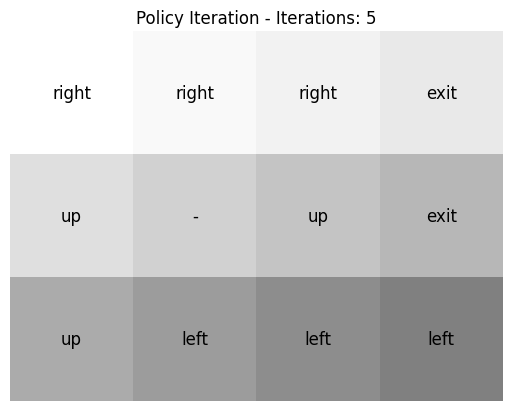

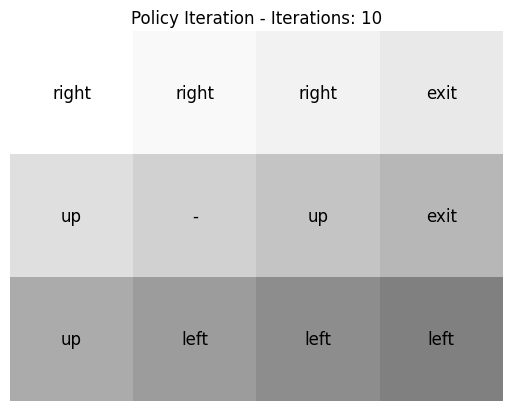

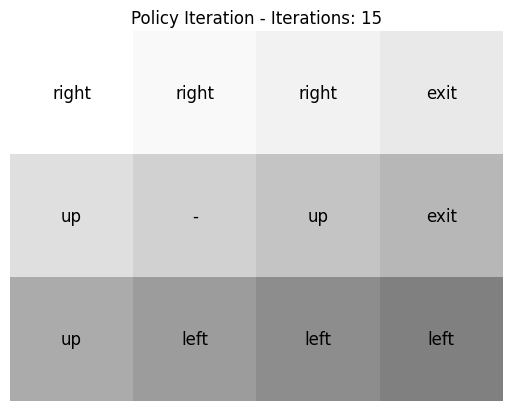

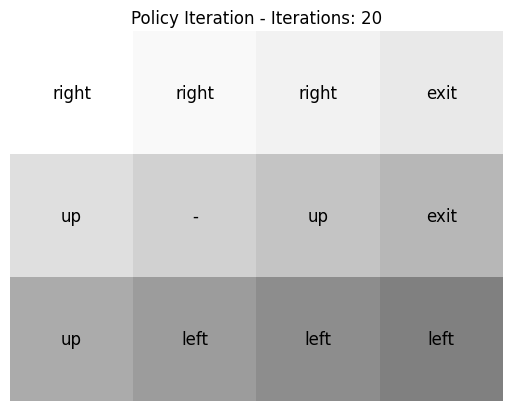

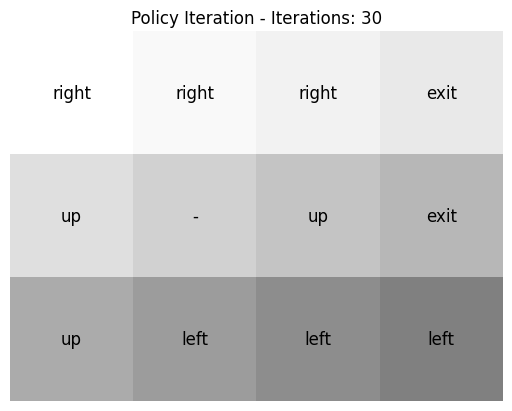

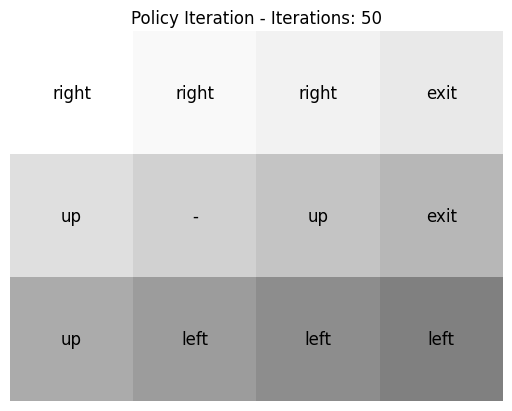

In [26]:
print("Policy Iteration (Gridworld)")

for i in [5, 10, 15, 20, 30, 50]:
    policy_iter = PolicyIteration(gridworld, discount=0.9, eval_iterations=10, policy_iterations=i)
    
    policy_iter.policy_iteration()

    policy_map = create_policy_map(policy_iter.policy, gridworld.nrows, gridworld.ncols)

    plot_policy(policy_map, f"Policy Iteration - Iterations: {i}")

Policy Iteration (Bridge)


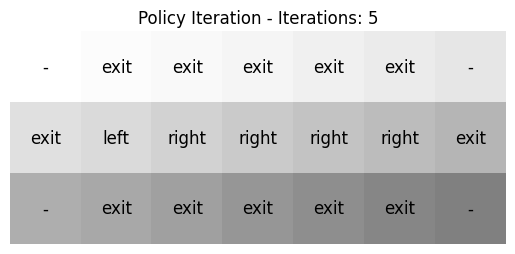

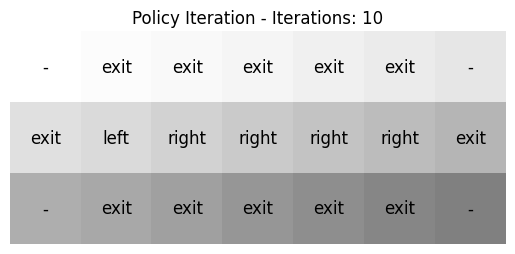

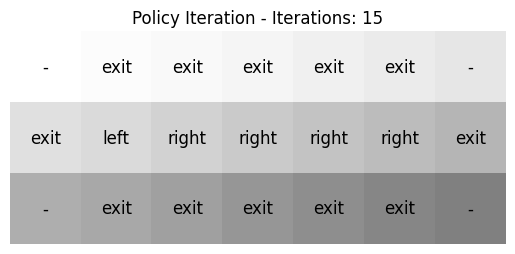

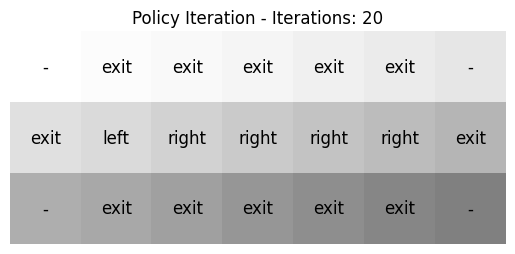

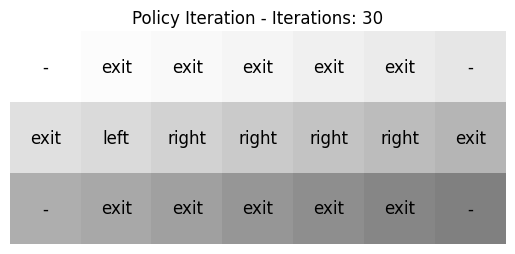

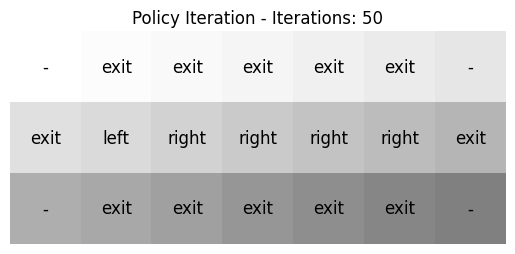

In [23]:
print("Policy Iteration (Bridge)")

for i in [5, 10, 15, 20, 30, 50]:
    policy_iter = PolicyIteration(bridge, discount=0.9, eval_iterations=10, policy_iterations=i)
    policy_iter.policy_iteration()

    policy_map = create_policy_map(policy_iter.policy, bridge.nrows, bridge.ncols)
    
    plot_policy(policy_map, f"Policy Iteration - Iterations: {i}")

La implementación de la iteración de las políticas es bastante rápido, incluso más que la de Value Iteration. En este caso, desde la 4ta iteración, la política converge a la óptima, a diferencia de la de iteración de valores que le tomó hasta la 10ma iteración.

Este comportamiento aún se repite en el ambiente de Bridge, donde la política converge a la óptima desde la 5ta iteración. Esto se debe a que la iteración de políticas es un método más directo para encontrar la política óptima, ya que se enfoca en mejorar la política actual en cada iteración, mientras que la iteración de valores se enfoca en mejorar el valor de los estados, lo que puede llevar a una convergencia más lenta.

## Cambio de descuento en los ambientes de Gridworld

Discount Variation (Gridworld)


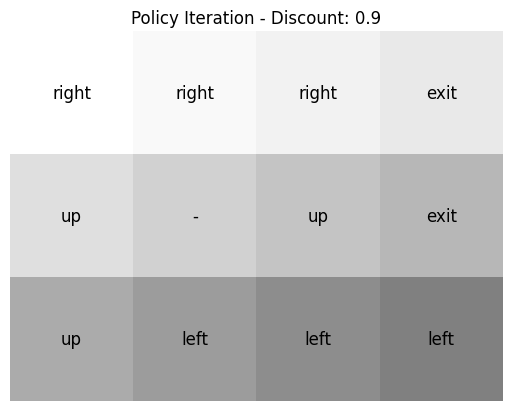

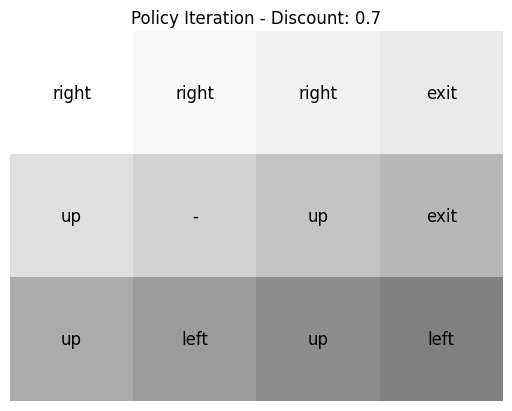

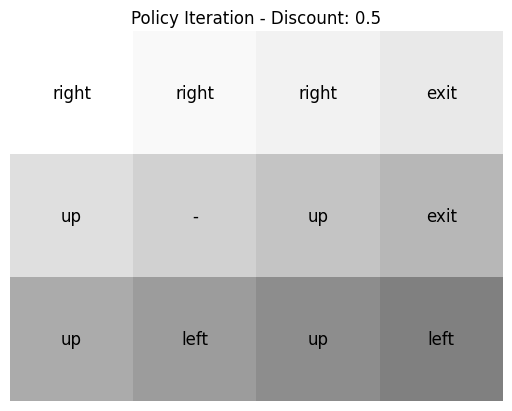

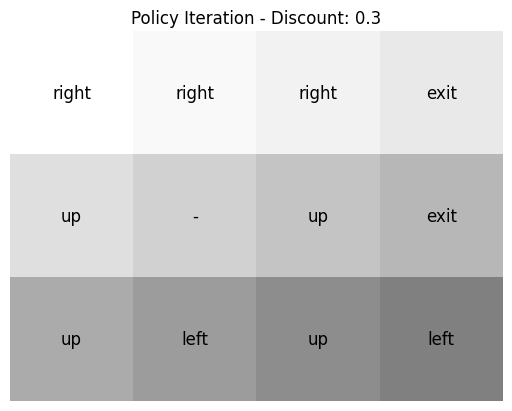

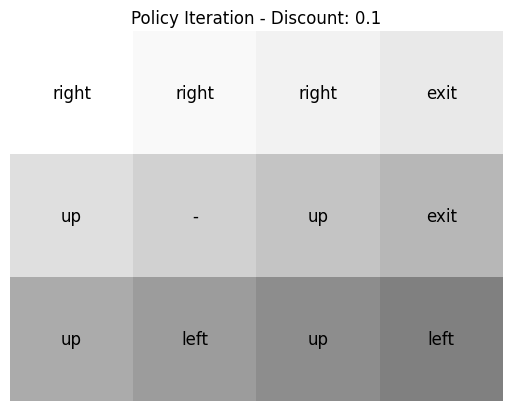

In [27]:
print("Discount Variation (Gridworld)")

for discount in np.round(np.linspace(0.9, 0.1, 5), 1):
    policy_iter = PolicyIteration(gridworld, discount=discount, eval_iterations=10, policy_iterations=20)
    policy_iter.policy_iteration()

    policy_map = create_policy_map(policy_iter.policy, gridworld.nrows, gridworld.ncols)
    
    plot_policy(policy_map, f"Policy Iteration - Discount: {discount}")

Discount Variation (Bridge)


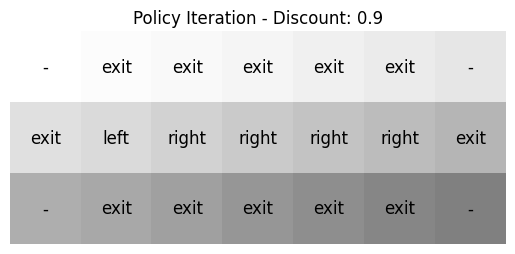

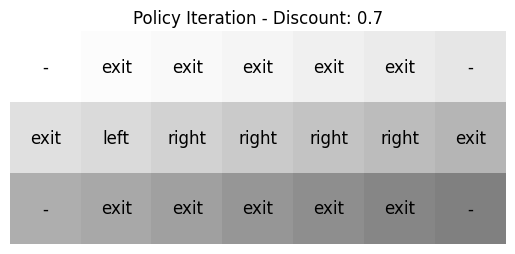

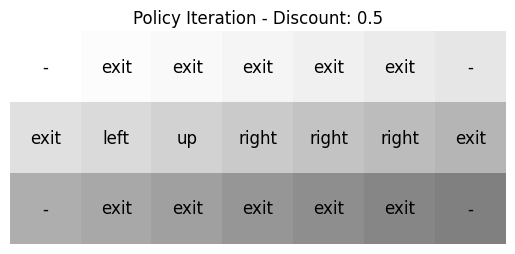

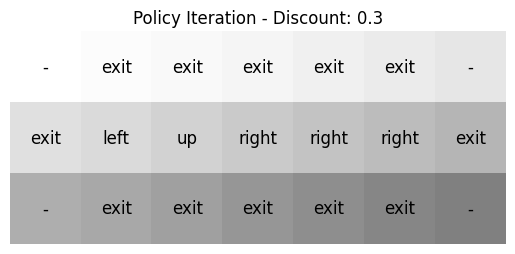

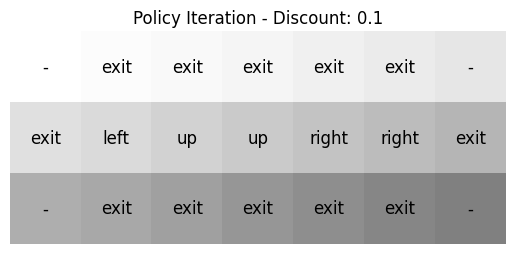

In [28]:
print("Discount Variation (Bridge)")
for discount in np.round(np.linspace(0.9, 0.1, 5), 1):
    policy_iter = PolicyIteration(bridge, discount=discount, eval_iterations=10, policy_iterations=20)
    policy_iter.policy_iteration()

    policy_map = create_policy_map(policy_iter.policy, bridge.nrows, bridge.ncols)
    
    plot_policy(policy_map, f"Policy Iteration - Discount: {discount}")

Como podemos ver, al actualizar el factor de descuento, la política óptima cambia, incluso haciendo que en algunos puntos prefiera ir hacia el estado terminal con recompensa negativa, en lugar de ir hacia el estado terminal con recompensa positiva. Esto se debe a que al reducir el factor de descuento, el agente valora menos las recompensas futuras, lo que puede llevar a una política que priorice las recompensas inmediatas, incluso si estas son negativas, en lugar de esperar por recompensas mayores en el futuro.